> # <p style="padding:10px">Data analysis</p>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
print("done")

done


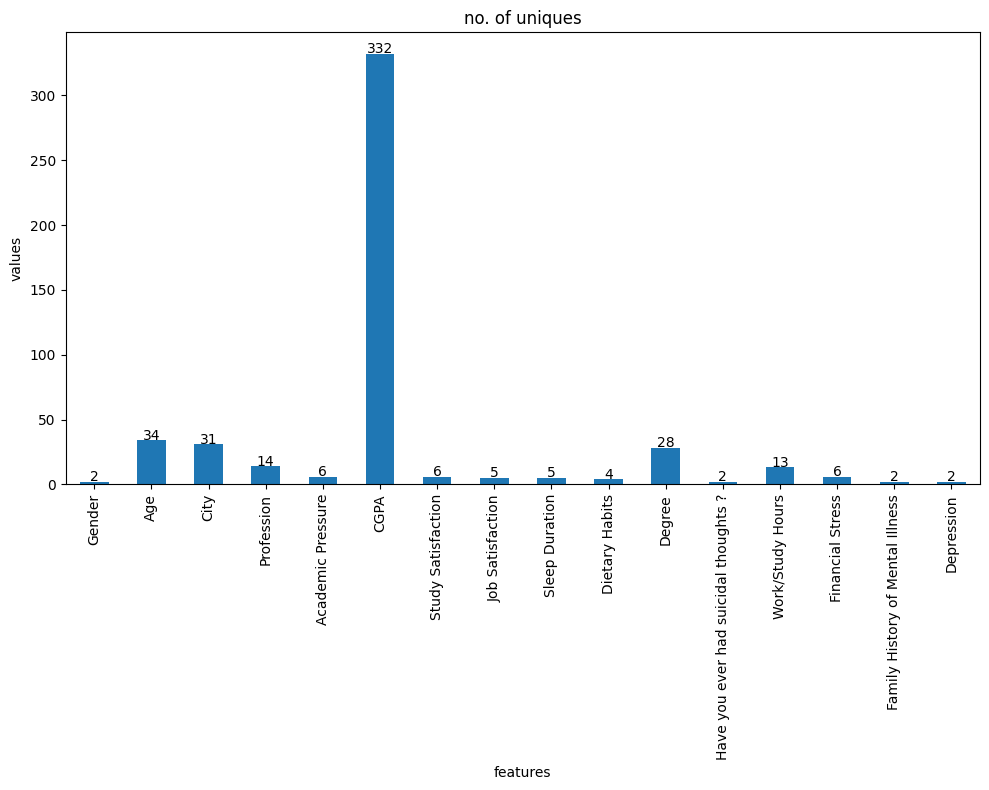

In [2]:
df = pd.read_csv("student_depression_dataset.csv")
df = df.drop(columns=['id'])

df = df.drop(columns=['Work Pressure']) # dropping work pressure as it has 27898 0s and 3 5s (high bais)

l1 = ['Saanvi','M.Tech','Bhavna',"'Less Delhi'",'City','3.0',"'Less than 5 Kalyan'",'Mira','Harsha','Vaanya','Gaurav','Harsh','Reyansh','Kibara','Rashi','ME','M.Com','Nalyan','Mihir','Nalini','Nandini',]

df = df.drop(df[df['City'].isin(l1) ].index)

uniques = df.nunique()

plt.figure(figsize=(10,8))
plott = uniques.plot(kind="bar")
for i, v in enumerate(uniques):
    plott.text(i, v + 0.5, str(v), ha='center')
plt.title("no. of uniques")
plt.xlabel("features")
plt.ylabel("values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


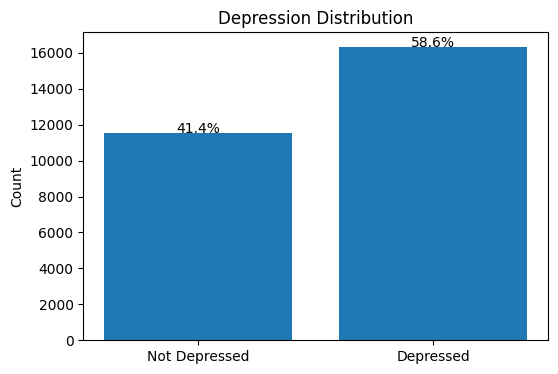

In [4]:
labels = ["Not Depressed", "Depressed"]
targets = df['Depression'].value_counts()
values = targets.sort_index()
total = values.sum()

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values)

# Add percentage on top
for i, v in enumerate(values):
    percent = (v / total) * 100
    plt.text(i, v + 0.5, f"{percent:.1f}%", ha='center')

plt.title("Depression Distribution")
plt.ylabel("Count")
plt.show()

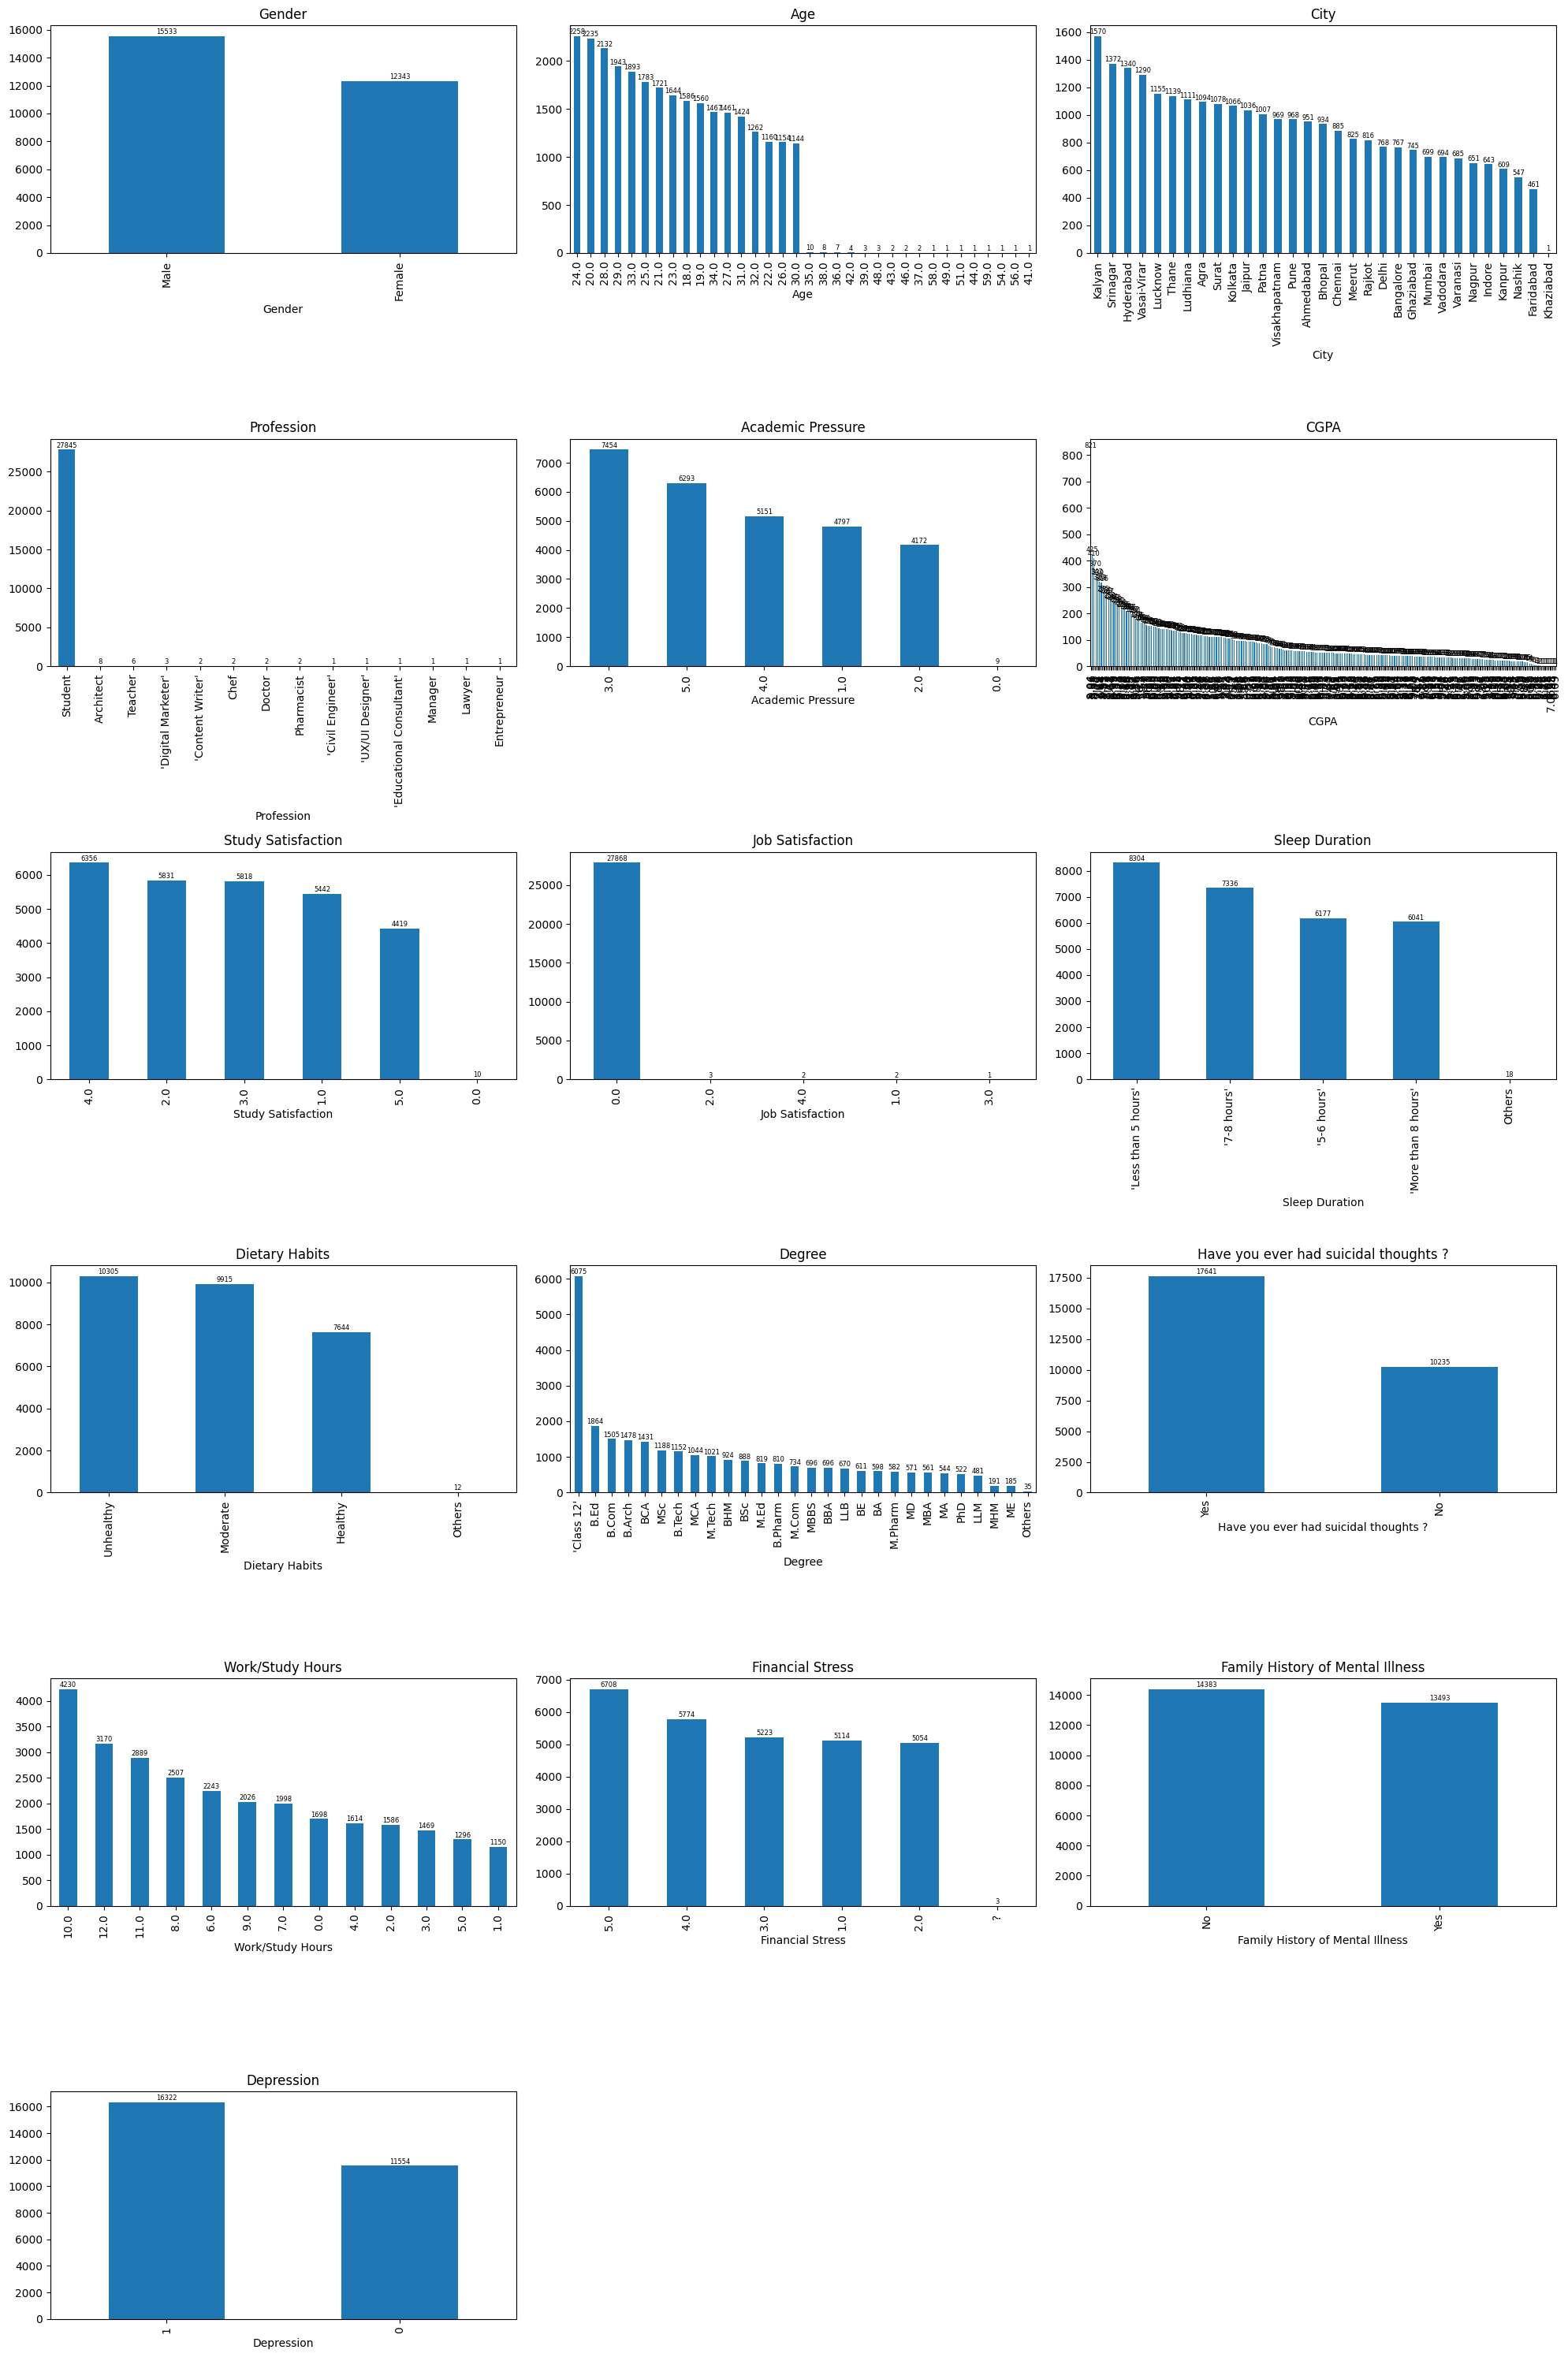

In [ ]:

columns = df.columns

n_cols = 3  
n_rows = (len(columns) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)
    
    counts = df[col].value_counts()
    counts.plot(kind='bar')
    
    plt.title(col)
    plt.xticks(rotation=90)
    
    for j, v in enumerate(counts):
        plt.text(j, v + max(counts)*0.01, str(v), ha='center', fontsize=6)
plt.tight_layout()
plt.show()

C:\Users\Ankit\AppData\Local\Temp\ipykernel_1900\2205091212.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


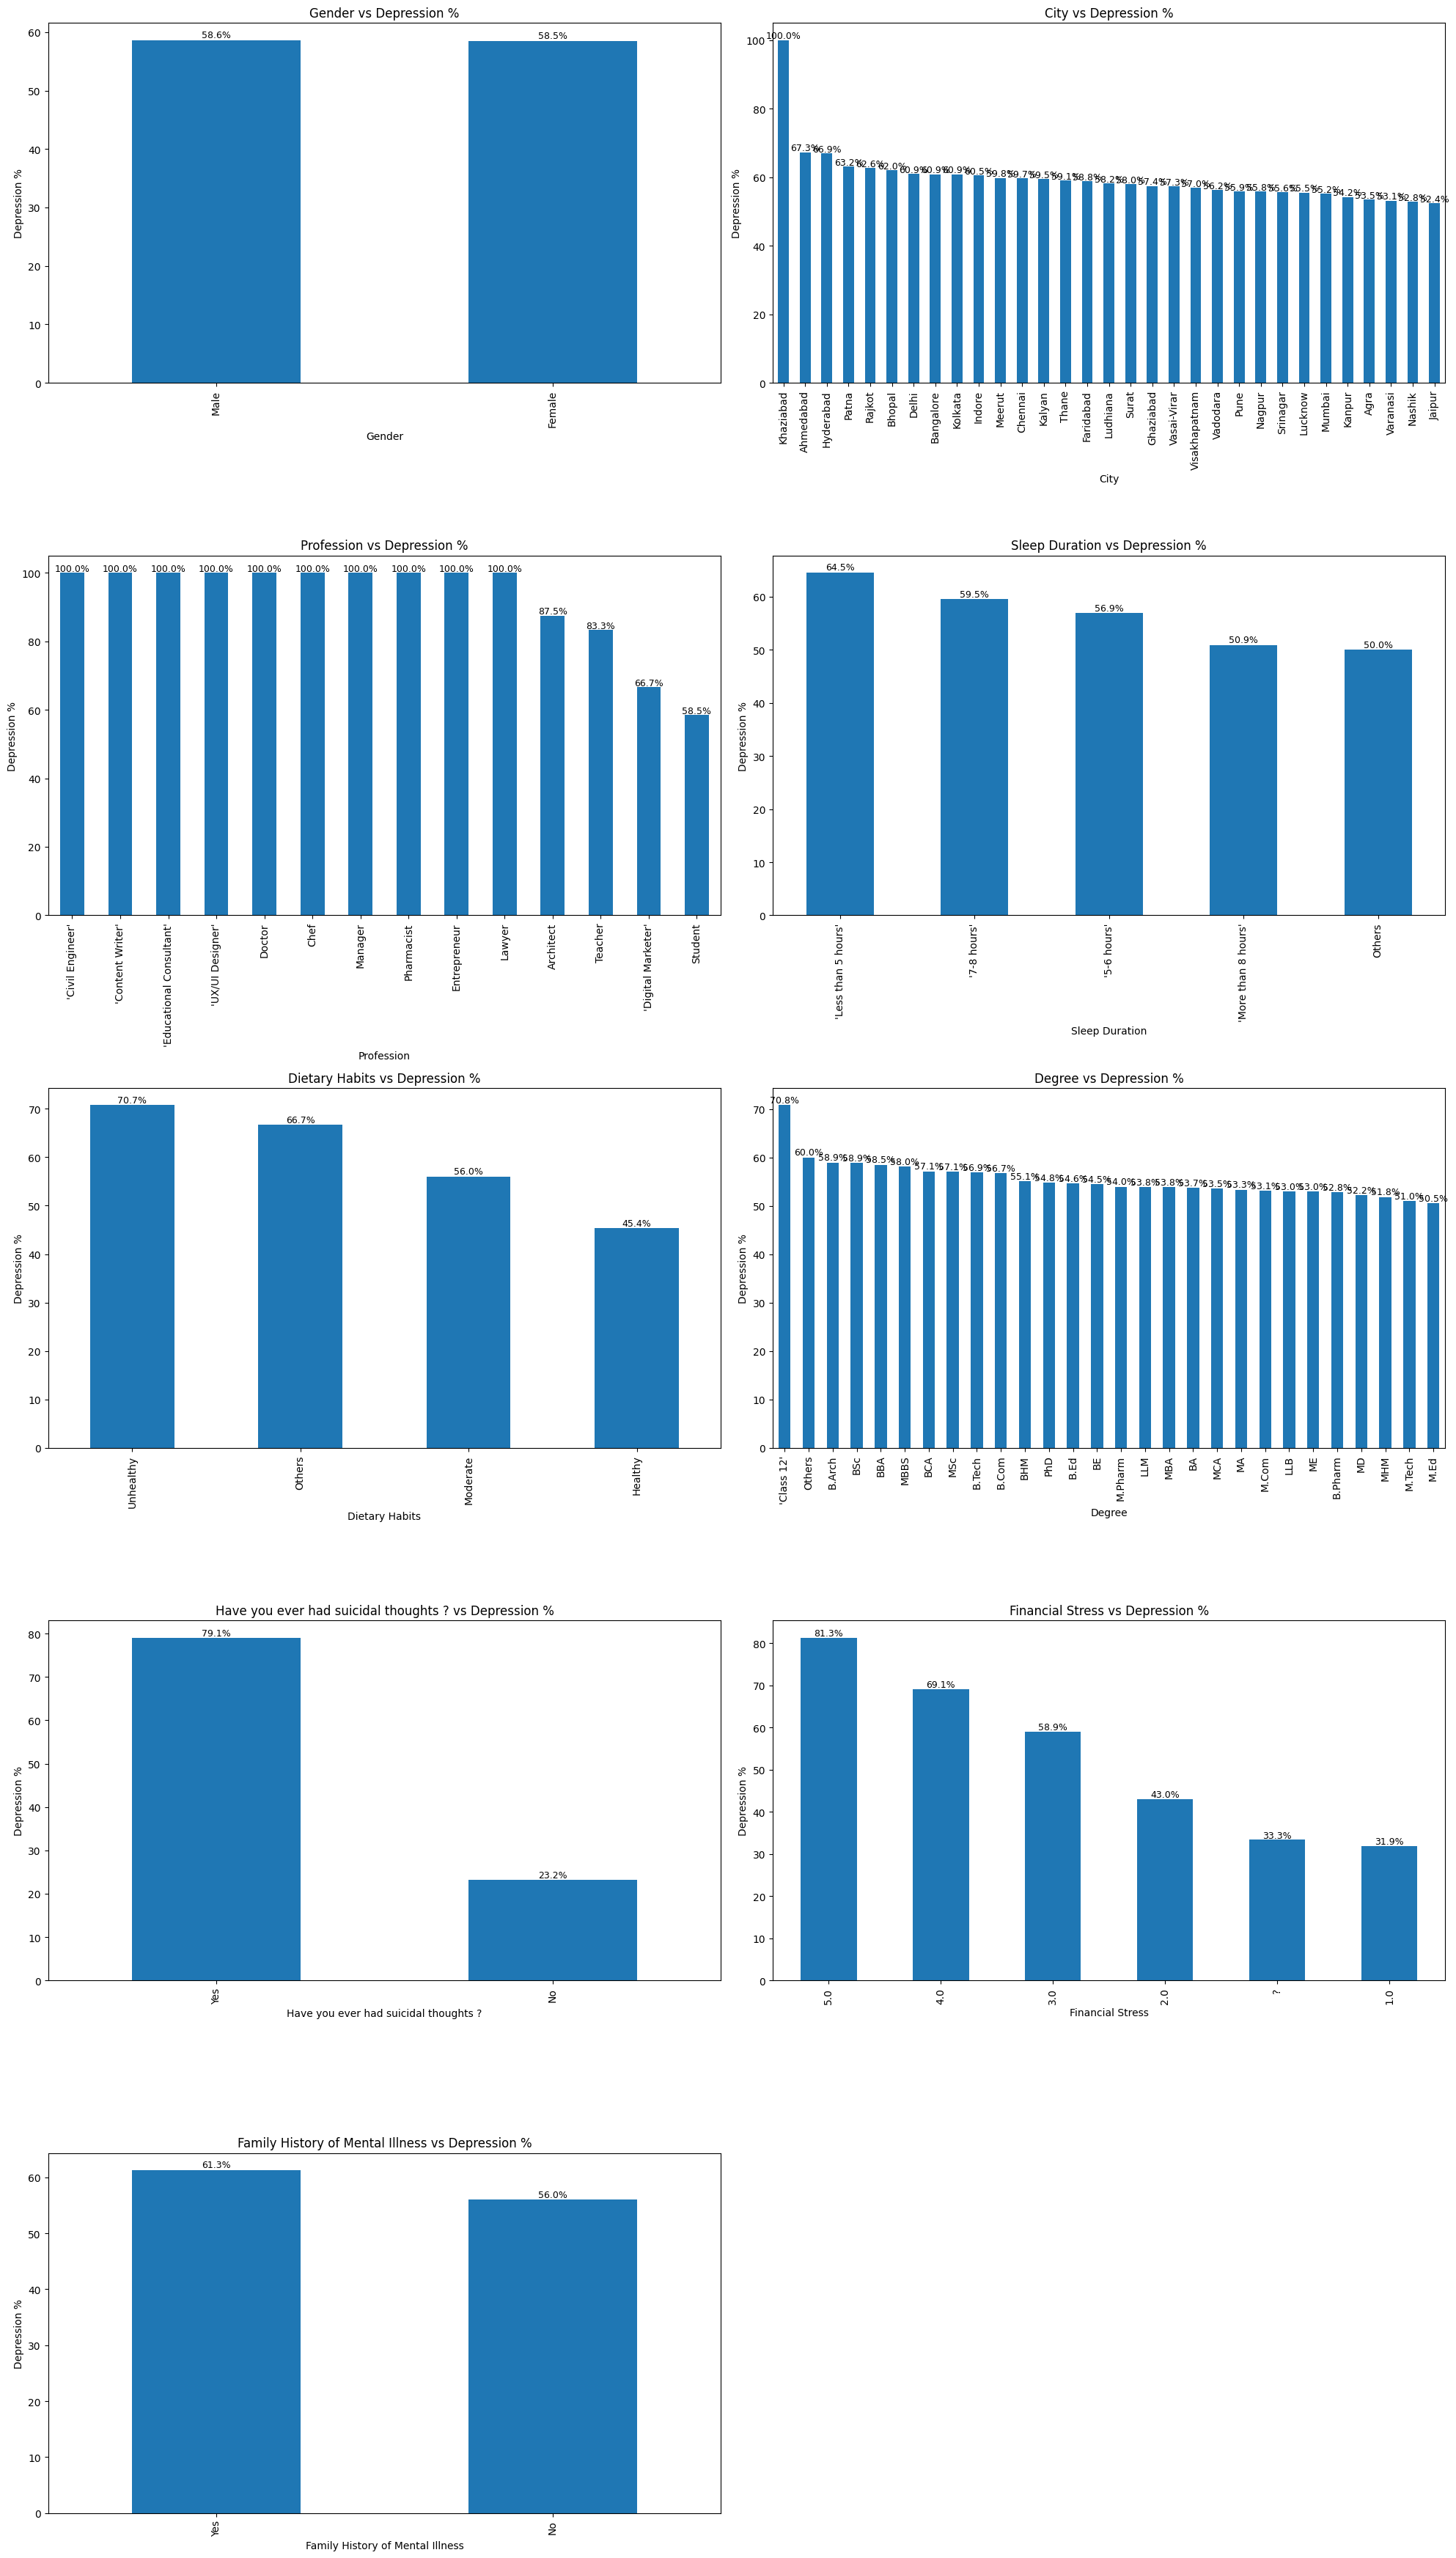

In [6]:

cat_cols = df.select_dtypes(include='object').columns

n_cols = 2
n_rows = (len(cat_cols) + 1) // 2

plt.figure(figsize=(20, 7 * n_rows))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    result = df.groupby(col)["Depression"].mean() * 100
    result = result.sort_values(ascending=False)
    
    result.plot(kind='bar',width=0.5)
    
    plt.title(f"{col} vs Depression %")
    plt.ylabel("Depression %")
    plt.xticks(rotation=90)
    
    # Add percentage labels
    for j, v in enumerate(result):
        plt.text(j, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()